# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["accuracy"] = pd.to_numeric(df["accuracy"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 19
Columns: ['commit', 'accuracy', 'status', 'description']


,commit,accuracy,status,description
0,baseline,0.8772,KEEP,"baseline run with rank=8, alpha=16, lr=1e-4, a..."
1,ec9d5a6,0.8887,KEEP,"increase LORA_RANK to 16, LORA_ALPHA to 32"
2,d1599cb,0.8939,KEEP,use muon optimizer instead of adamw
3,20a5908,0.8907,DISCARD,increase LEARNING_RATE to 2e-4
4,9a11e31,0.8980,KEEP,"increase LORA_RANK to 32, LORA_ALPHA to 64"
5,4b1bcdf,0.8939,DISCARD,"increase LORA_RANK to 64, LORA_ALPHA to 128"
6,95352f7,0.8980,DISCARD,add o_einsum to LoRA modules
7,6b8996c,0.8907,DISCARD,decrease LEARNING_RATE to 5e-5
8,97227db,0.8855,DISCARD,change SEED to 123
9,c3ce543,0.8887,DISCARD,change BATCH_SIZE to 4


In [3]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    14
KEEP        5

Keep rate: 5/19 = 26.3%


In [4]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    accuracy = row["accuracy"]
    desc = row["description"]
    print(f"  #{i:3d}  accuracy={accuracy:.6f}  {desc}")

KEPT experiments (5 total):

  #  0  accuracy=0.877200  baseline run with rank=8, alpha=16, lr=1e-4, adamw
  #  1  accuracy=0.888700  increase LORA_RANK to 16, LORA_ALPHA to 32
  #  2  accuracy=0.893900  use muon optimizer instead of adamw
  #  4  accuracy=0.898000  increase LORA_RANK to 32, LORA_ALPHA to 64
  # 14  accuracy=0.901100  change LORA_ALPHA to 32 (1:1 scaling)


## Accuracy Over Time

Track how the best (kept) accuracy evolves as experiments progress. The running maximum shows the "frontier" -- the best result achieved so far.

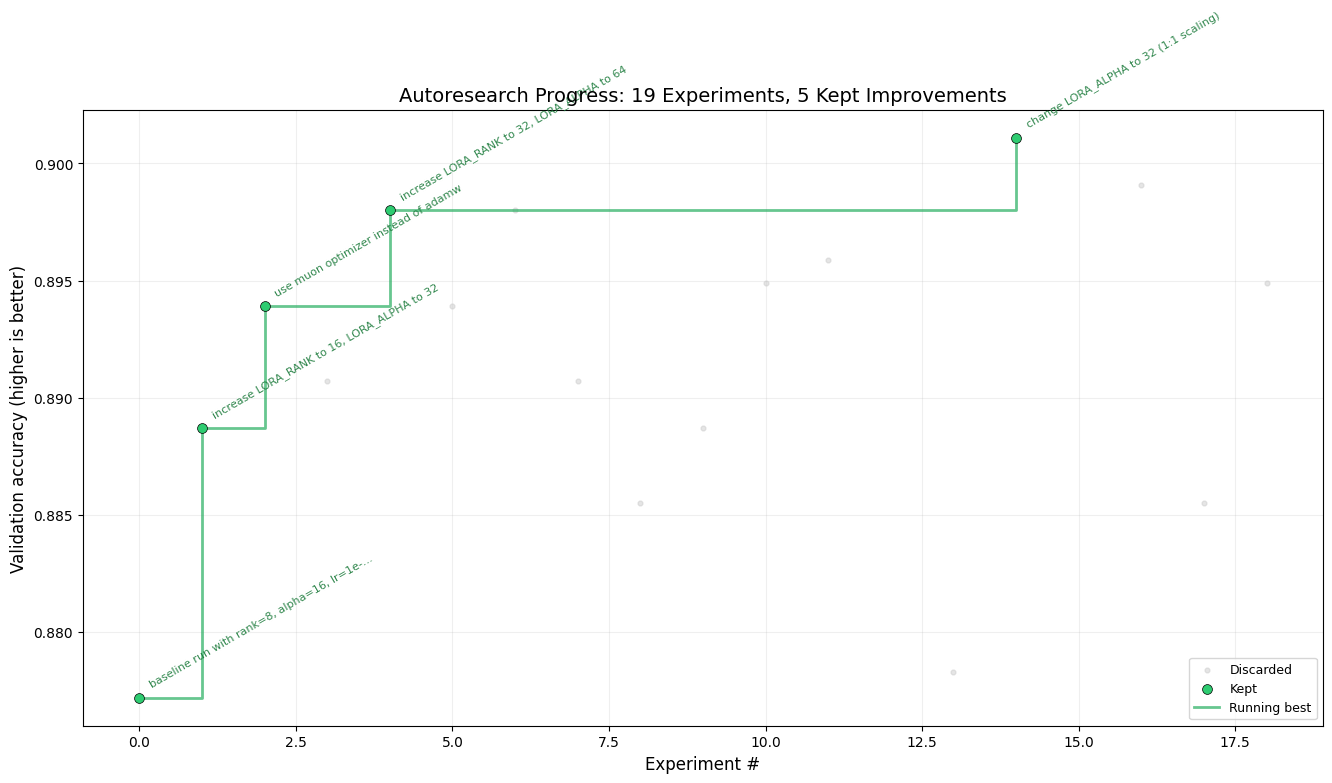

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_accuracy = valid.loc[0, "accuracy"]

# Only plot points at or above baseline (the interesting region)
above = valid[valid["accuracy"] >= baseline_accuracy - 0.0005]

# Plot discarded as faint background dots
disc = above[above["status"] == "DISCARD"]
ax.scatter(disc.index, disc["accuracy"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = above[above["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["accuracy"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_accuracy = valid.loc[kept_mask, "accuracy"]
running_max = kept_accuracy.cummax() # Changed to cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, accuracy in zip(kept_idx, kept_accuracy):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, accuracy),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")
    
# Fixed fallback variable from baseline_bpb to baseline_accuracy
best = running_max.iloc[-1] if len(running_max) > 0 else baseline_accuracy
n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])

ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation accuracy (higher is better)", fontsize=12) # Updated label
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=9) # Moved to lower right so the rising line doesn't collide with it
ax.grid(True, alpha=0.2)

# Y-axis: from just below baseline to just above best
margin = (best - baseline_accuracy) * 0.15
# Added absolute value fallback just in case best == baseline